In [3]:
include("parse.jl")
include("plots.jl")

abstract_vs_main_category_sort (generic function with 1 method)

In [4]:
using LDA_CGS
using Random
using WordCloud
using Colors
using Statistics

In [5]:
MAIN_CATEGORY = "math"
STARTING_YEAR = 2012

USELESS_WORDS = Set([
    "not",
    "the",
    "are",
    "and",
    "from",
    "via",
    "but",
    "also",
    "with",
    "for",
    "into",
    "onto",
    "this",
    "that",
    "those",
    "these",
    "using",
    "they",
    "them",
    "their",
    "our",
    "its",
    "any",
    "let",
    "has",
    "due",
    "out",
    "was",
    "vere",
    "his",
    "her",
    "she",
    "which",
    "can",
    "nor",
    "how",
    "new",
    "all", 
    "have",
    "then",
    "than",
])

function parse_authors(authors)
    filtered = authors .|> filter(!isempty)
    return map(filtered) do author
        join(author, " ")
    end
end

function get_main_category(categories_str::AbstractString)
    for c in eachsplit(categories_str, ' ')
        if startswith(c, MAIN_CATEGORY)
            return c
        end
    end
    return missing
end

function has_main_category(categories_str::AbstractString)
    for c in eachsplit(categories_str, ' ')
        if startswith(c, MAIN_CATEGORY)
            return true
        end
    end
    return false
end

function normalize_text(s::AbstractString)
    words = split(s |> lowercase, r"[ ,.!?/\\\]\[\t*&()<>=0-9%$@#;:\"'|\n\r{}]+") |> Set
    filter!(w -> length(w) > 2, words)
    bad_start = r"[-_^]+"
    filter!(!startswith(bad_start), words)
    filter!(!endswith(bad_start), words)
    setdiff!(words, USELESS_WORDS)
    return words |> collect
end

default_dict = Dict{Symbol,Union{Type,Tuple{Type,<:Function}}}(
    :categories => (String, get_main_category),
    :title => (Vector{String}, normalize_text),
    :abstract => (Vector{String}, normalize_text),
    :update_date => (Date, s -> Date(s)),
    :authors_parsed => (Vector{String}, parse_authors)
)

default_filters = Dict{Symbol,Function}(
    :update_date => (s -> Date(s) |> year |> x -> x >= STARTING_YEAR),
    :categories => has_main_category,
)

Dict{Symbol, Function} with 2 entries:
  :update_date => #28
  :categories  => has_main_category

In [6]:
df = load_data("arxiv-metadata-oai-snapshot.json", fields=default_dict, filters=default_filters, start_lines=100000)
first(df, 5)

Row,date,abstract,categories,title,authors
,Date,Array…,String,Array…,Array…
1,2013-10-15,"[""dyadic"", ""compute"", ""hardy"", ""description"", ""result"", ""paper"", ""consequence"", ""alpha"", ""grid"", ""norm"", ""spaces"", ""r^n"", ""special"", ""show"", ""h^p"", ""terms"", ""atoms""]",math.CA,"[""dyadic"", ""alpha""]","[""Abu-Shammala Wael"", ""Torchinsky Alberto""]"
2,2014-07-31,"[""lieb"", ""constant"", ""semi-definite"", ""matrices"", ""subject"", ""real"", ""lower"", ""improve"", ""sometimes"", ""prove"" … ""pfaffian"", ""`real"", ""called"", ""determinants"", ""norm"", ""inequality"", ""functionals"", ""problem"", ""inequalities"", ""esz""]",math.CA,"[""real"", ""linear"", ""pfaffians"", ""products"", ""hafnians"", ""functionals""]","[""Frenkel Péter E.""]"
3,2013-10-15,"[""infty"", ""singular"", ""interpolation"", ""paper"", ""spaces"", ""acting"", ""hardy-lorentz"", ""integrals"", ""operators"", ""atomic"", ""elements"", ""consider"", ""discuss"", ""properties"", ""r^n"", ""behavior"", ""other"", ""decomposition""]",math.CA,"[""hardy-lorentz"", ""r^n"", ""spaces""]","[""Abu-Shammala Wael"", ""Torchinsky Alberto""]"
4,2012-03-06,"[""compact"", ""neither"", ""harmonic"", ""give"", ""covering"", ""viewpoint"", ""more"", ""suitable"", ""need"", ""injectivity"" … ""condition"", ""differential"", ""sequence"", ""geometric"", ""uses"", ""open"", ""spectral"", ""koll"", ""complete"", ""type""]",math.AG,"[""injectivity"", ""transcendental"", ""theorem"", ""koll"", ""approach""]","[""Fujino Osamu""]"
5,2012-04-11,"[""commensurable"", ""groups"", ""generalization"", ""connected"", ""give"", ""balls"", ""answer"", ""growth"", ""theory"", ""weakly"" … ""interpreted"", ""particular"", ""discuss"", ""shadow"", ""polynomial"", ""treat"", ""results"", ""solvable"", ""application"", ""burago""]",math.GR,"[""growth"", ""groups"", ""compact"", ""locally"", ""polynomial"", ""shape"", ""geometry"", ""balls"", ""large""]","[""Breuillard Emmanuel""]"


In [7]:
size(df)

(4329, 5)

In [8]:
function zero_pair(obj, zero=0)
    return obj => zero
end

zero_pair (generic function with 2 methods)

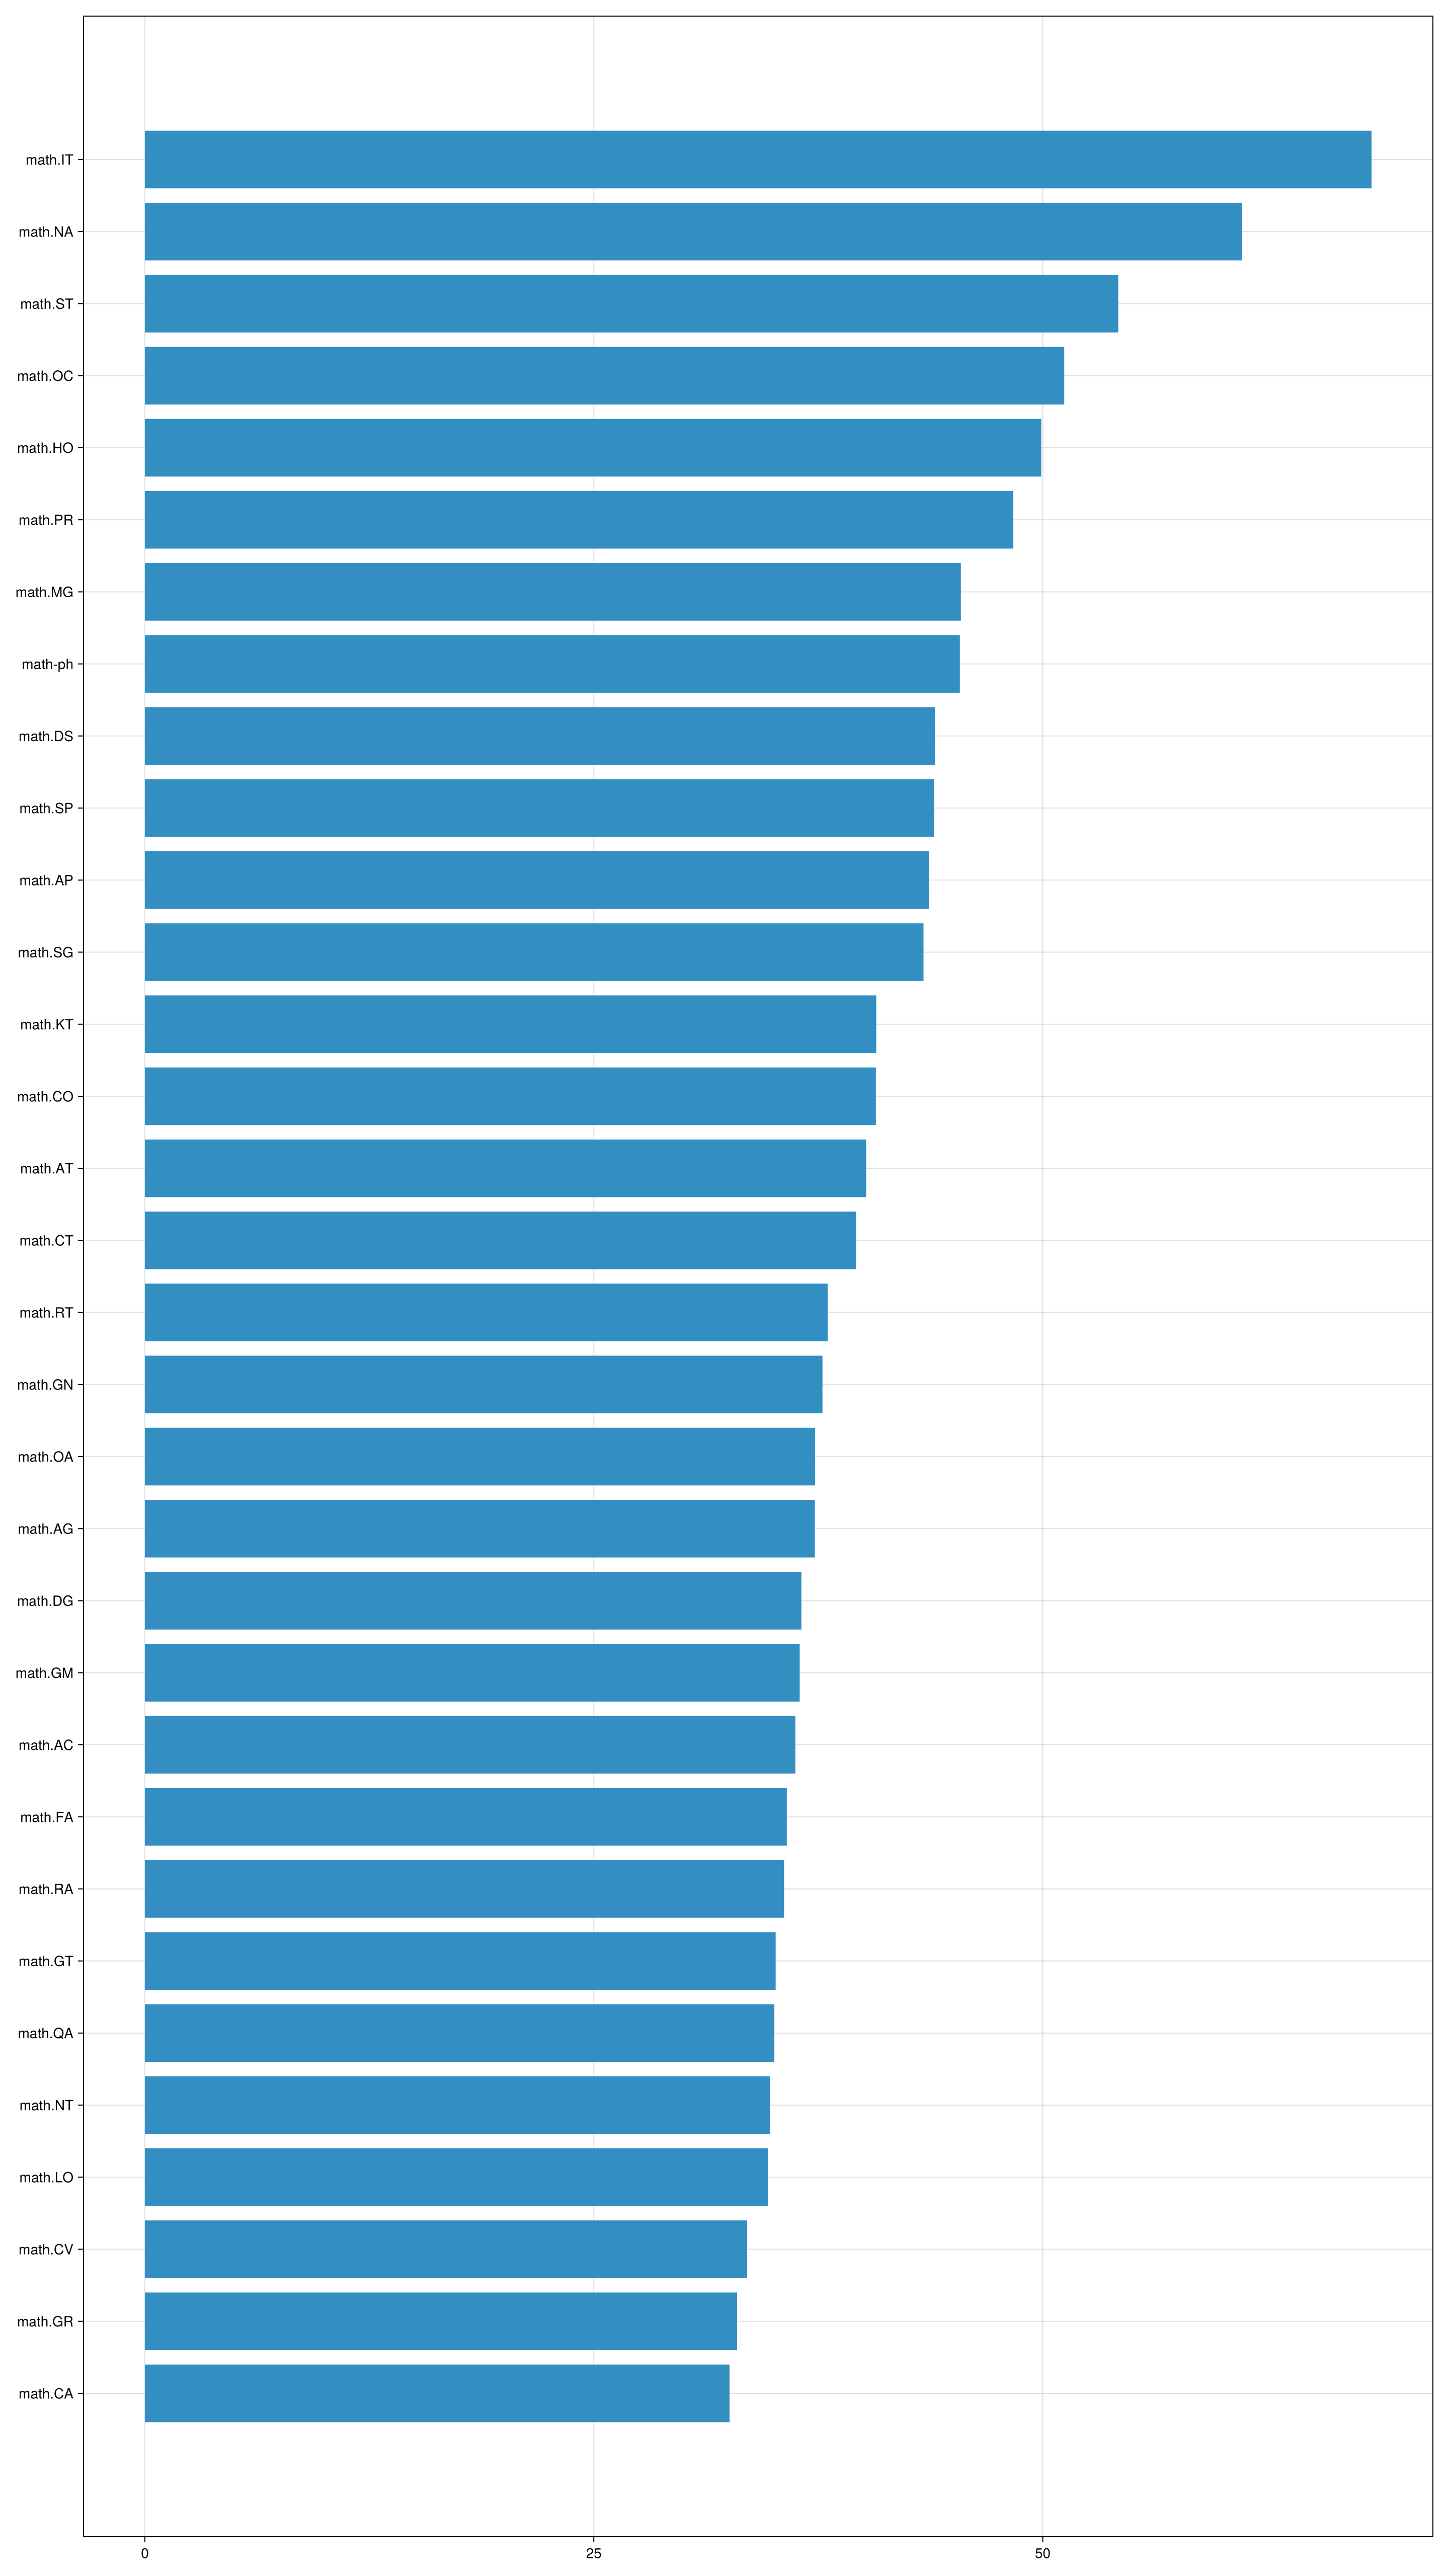

In [9]:
function abstract_vs_category_sort(df::DataFrame)
    category_counts = df[:, :categories] |> unique .|> (e -> e => [0, 0]) |> Dict
    for (name, alen) in zip(df[:, :categories], df[:, :abstract])
        category_counts[name][1] += alen |> length
        category_counts[name][2] += 1
    end
    categories = category_counts |> collect .|> (p -> p.first => p.second[1] / p.second[2])
    sorted_names = sort(categories, by=last)
    tick_names = sorted_names .|> first
    fig = Figure(size=(1440, 2560))
    ax = Axis(
        fig[1,1],
        yticks=(eachindex(tick_names), tick_names),
    )
    barplot!(ax, sorted_names .|> last; direction=:x)
    return fig
end

abstract_vs_category_sort(df)

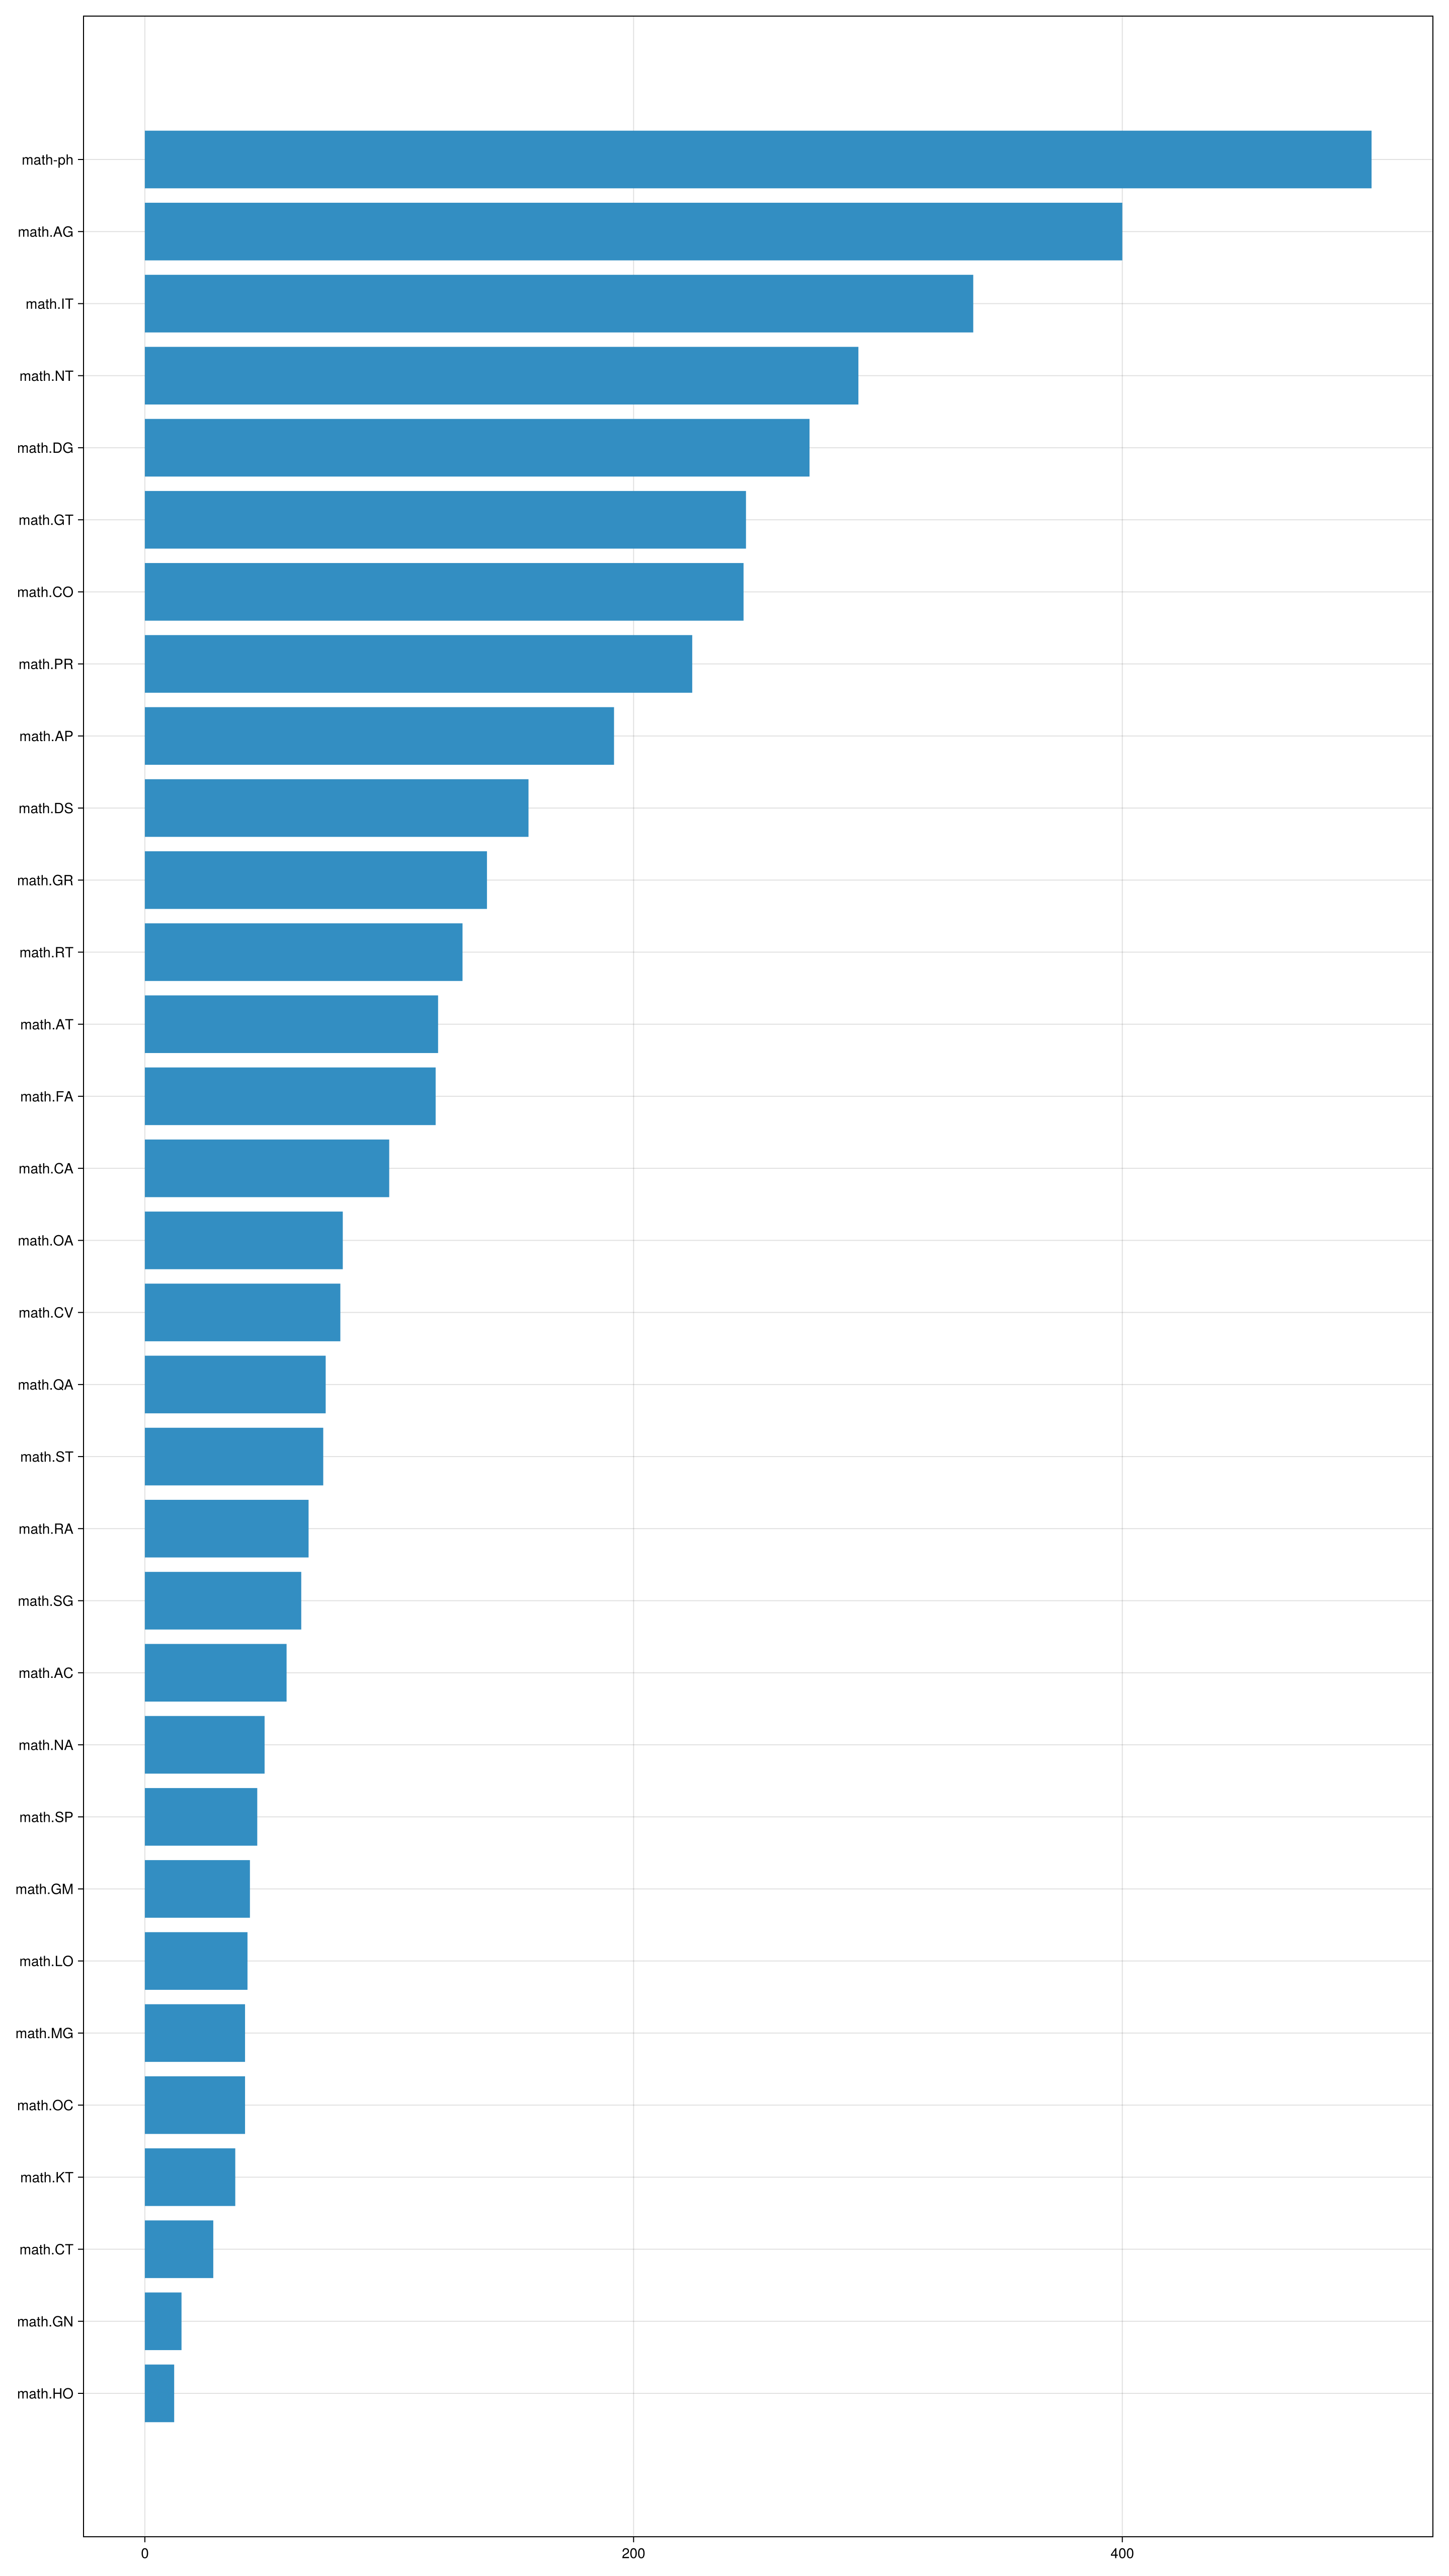

In [10]:
function article_types_sort(df::DataFrame)
    name_counts = df[:, :categories] |> unique .|> zero_pair |> Dict
    for name in df[:, :categories]
        name_counts[name] += 1
    end
    sorted_names = sort(name_counts |> collect, by=last)
    tick_names = sorted_names .|> first
    fig = Figure(size=(1440, 2560))
    ax = Axis(
        fig[1,1],
        yticks=(eachindex(tick_names), tick_names),
    )
    barplot!(ax, sorted_names .|> last; direction=:x)
    return fig
end

article_types_sort(df)

In [11]:
length(unique(df[:, :categories]))

32

In [12]:
docs = [
    vcat(t, ab, at)
    for (t, ab, at) in zip(df.title, df.abstract, df.authors)
]

4329-element Vector{Vector{String}}:
 ["dyadic", "alpha", "dyadic", "compute", "hardy", "description", "result", "paper", "consequence", "alpha"  …  "norm", "spaces", "r^n", "special", "show", "h^p", "terms", "atoms", "Abu-Shammala Wael", "Torchinsky Alberto"]
 ["real", "linear", "pfaffians", "products", "hafnians", "functionals", "lieb", "constant", "semi-definite", "matrices"  …  "`real", "called", "determinants", "norm", "inequality", "functionals", "problem", "inequalities", "esz", "Frenkel Péter E."]
 ["hardy-lorentz", "r^n", "spaces", "infty", "singular", "interpolation", "paper", "spaces", "acting", "hardy-lorentz"  …  "elements", "consider", "discuss", "properties", "r^n", "behavior", "other", "decomposition", "Abu-Shammala Wael", "Torchinsky Alberto"]
 ["injectivity", "transcendental", "theorem", "koll", "approach", "compact", "neither", "harmonic", "give", "covering"  …  "differential", "sequence", "geometric", "uses", "open", "spectral", "koll", "complete", "type", "Fujino O

In [13]:
vocab = Dict{String,Int}()
next_id = 1
for tokens in docs
    for w in tokens
        if !haskey(vocab, w)
            vocab[w] = next_id
            next_id += 1
        end
    end
end

In [14]:
function build_corpus(docs_tokens, vocab)
    corpus = Vector{Vector{Tuple{Int,Int}}}(undef, length(docs_tokens))
    for i in 1:length(docs_tokens)
        tokens = docs_tokens[i]
        freq = Dict{Int,Int}()
        for w in tokens
            vid = vocab[w]
            freq[vid] = get(freq, vid, 0) + 1
        end
        corpus[i] = [(vid, freq[vid]) for vid in keys(freq)]
    end
    return corpus
end

build_corpus (generic function with 1 method)

In [15]:
X = build_corpus(docs, vocab)

4329-element Vector{Vector{Tuple{Int64, Int64}}}:
 [(5, 1), (16, 1), (12, 1), (8, 1), (17, 1), (1, 2), (19, 1), (6, 1), (11, 1), (9, 1), (14, 1), (3, 1), (7, 1), (4, 1), (13, 1), (15, 1), (2, 2), (10, 1), (18, 1)]
 [(35, 1), (20, 2), (52, 1), (24, 1), (28, 1), (30, 1), (37, 1), (23, 1), (53, 1), (22, 1)  …  (48, 1), (34, 1), (50, 1), (21, 2), (54, 1), (27, 1), (38, 1), (26, 1), (10, 1), (42, 1)]
 [(56, 1), (55, 2), (58, 1), (60, 1), (12, 2), (19, 1), (67, 1), (11, 2), (68, 1), (69, 1), (64, 1), (61, 1), (7, 1), (66, 1), (57, 1), (59, 1), (65, 1), (63, 1), (18, 1), (62, 1)]
 [(110, 1), (73, 2), (112, 1), (90, 1), (86, 1), (104, 1), (91, 1), (75, 1), (111, 1), (92, 1)  …  (101, 1), (78, 1), (105, 1), (72, 2), (83, 1), (99, 1), (89, 1), (80, 1), (96, 1), (97, 1)]
 [(114, 2), (123, 1), (136, 1), (117, 2), (145, 1), (164, 1), (115, 2), (153, 1), (151, 1), (139, 1)  …  (166, 1), (14, 1), (149, 1), (155, 1), (143, 1), (113, 2), (65, 1), (165, 1), (142, 1), (134, 1)]
 [(220, 1), (197, 1), (215

In [16]:
Random.seed!(1234)
N = length(X)

test_idx = randperm(N)[1:round(Int, 0.2*N)]
train_idx = setdiff(1:N, test_idx)

train_subset = X[train_idx]
test_subset  = X[test_idx]

866-element Vector{Vector{Tuple{Int64, Int64}}}:
 [(1860, 2), (2470, 1), (797, 1), (1268, 1), (4540, 2), (1946, 2), (697, 1), (1764, 1), (847, 2), (2563, 1)  …  (22943, 1), (4949, 1), (24102, 1), (16301, 2), (24101, 1), (897, 1), (3150, 2), (1435, 1), (4531, 2), (3418, 1)]
 [(684, 1), (1033, 1), (711, 1), (4111, 1), (2802, 1), (6, 1), (267, 1), (3688, 1), (1619, 1), (5781, 1)  …  (14, 1), (178, 1), (96, 1), (1044, 1), (97, 1), (1034, 1), (4297, 2), (496, 1), (1780, 1), (683, 1)]
 [(25031, 1), (3202, 1), (913, 1), (648, 2), (720, 1), (569, 1), (926, 1), (2442, 1), (15941, 1), (319, 1)  …  (713, 1), (3694, 1), (1217, 1), (2727, 1), (3701, 1), (1326, 1), (2190, 1), (2029, 1), (2978, 1), (1512, 1)]
 [(2217, 1), (15199, 1), (2523, 1), (2350, 1), (111, 1), (11, 1), (45, 1), (237, 2), (15197, 1), (2525, 1)  …  (3148, 1), (2527, 1), (1294, 1), (612, 1), (15198, 1), (2321, 1), (15196, 1), (2362, 1), (1779, 1), (15195, 1)]
 [(706, 1), (781, 1), (9510, 1), (7147, 2), (7146, 2), (5282, 2), (7129, 

In [17]:
println("Rozmiar train: ", length(train_subset))
println("Rozmiar test: ", length(test_subset))

Rozmiar train: 3463
Rozmiar test: 866


In [18]:
K = 30
V = length(vocab)
burnin  = 100
samples  = 200

lda = LDA(K, V)
run_LDA(lda, train_subset, test_subset, burnin, samples)

Burn-in (period=100)...
epoch=1
epoch=2
epoch=3
epoch=4
epoch=5
epoch=6
epoch=7
epoch=8
epoch=9
epoch=10
epoch=11
epoch=12
epoch=13
epoch=14
epoch=15
epoch=16
epoch=17
epoch=18
epoch=19
epoch=20
epoch=21
epoch=22
epoch=23
epoch=24
epoch=25
epoch=26
epoch=27
epoch=28
epoch=29
epoch=30
epoch=31
epoch=32
epoch=33
epoch=34
epoch=35
epoch=36
epoch=37
epoch=38
epoch=39
epoch=40
epoch=41
epoch=42
epoch=43
epoch=44
epoch=45
epoch=46
epoch=47
epoch=48
epoch=49
epoch=50
epoch=51
epoch=52
epoch=53
epoch=54
epoch=55
epoch=56
epoch=57
epoch=58
epoch=59
epoch=60
epoch=61
epoch=62
epoch=63
epoch=64
epoch=65
epoch=66
epoch=67
epoch=68
epoch=69
epoch=70
epoch=71
epoch=72
epoch=73
epoch=74
epoch=75
epoch=76
epoch=77
epoch=78
epoch=79
epoch=80
epoch=81
epoch=82
epoch=83
epoch=84
epoch=85
epoch=86
epoch=87
epoch=88
epoch=89
epoch=90
epoch=91
epoch=92
epoch=93
epoch=94
epoch=95
epoch=96
epoch=97
epoch=98
epoch=99
epoch=100
Sampling from the posterior...
epoch=1, PPL=9.461381845553387
epoch=2, PPL=9.3984394

In [19]:
lda.Ndk_mean

3463×30 Matrix{Float64}:
 0.005   0.01   1.855   0.06   0.15   0.1    …   0.195   0.02   0.645   3.3
 0.09    0.02   9.875   0.03   0.01   0.0        0.26    0.025  0.015   0.275
 0.025   0.025  0.035   0.025  0.03   0.0        0.09    0.005  0.03    0.06
 0.075   0.015  0.05    0.035  0.035  0.03       8.32    0.015  0.04    6.075
 0.285   0.09   0.02    0.3    3.97   0.025      0.09    0.115  0.015   0.26
 0.13    0.07   0.04    1.875  0.015  0.23   …   0.075   0.385  0.1     0.06
 0.555   0.005  0.47    2.49   0.015  0.095      0.095   0.17   0.005   0.16
 0.21    0.33   2.34    3.535  0.035  0.005      0.07    0.04   0.08    0.765
 1.13    0.015  0.035   0.005  0.015  0.175      0.035   0.055  0.005   0.06
 0.07    0.04   0.05    0.755  0.075  0.11       0.635   2.725  0.05    0.07
 0.94   11.36   0.1     0.005  0.06   0.09   …   0.545   0.015  0.02    1.215
 0.565   0.01   0.075   5.15   0.0    0.145      0.385   0.065  0.02    0.44
 0.02    0.0    0.515  17.645  0.005  0.02      

In [20]:
dominant_topics_test = map(d -> argmax(lda.Ndk_mean[d, :]), 1:size(test_subset, 1))

866-element Vector{Int64}:
 18
  3
 21
 11
 11
 21
 18
 18
 18
 16
 26
 13
  4
  ⋮
  8
 11
  8
  8
 26
  8
 11
  8
  8
 21
  7
 25

In [21]:
function plot_topic_words(lda, vocab, topic_id; top_n=10)
    id2word = Dict(v => k for (k,v) in vocab)

    word_counts = lda.Nkv_mean[topic_id, :]
    top_ids = sortperm(word_counts, rev=true)[1:top_n]

    words = [id2word[i] for i in top_ids]
    values = word_counts[top_ids]

    fig = Figure()
    ax = Axis(fig[1,1], yticks=(1:top_n, words))

    barplot!(ax, values; direction=:x)

    fig
end

plot_topic_words (generic function with 1 method)

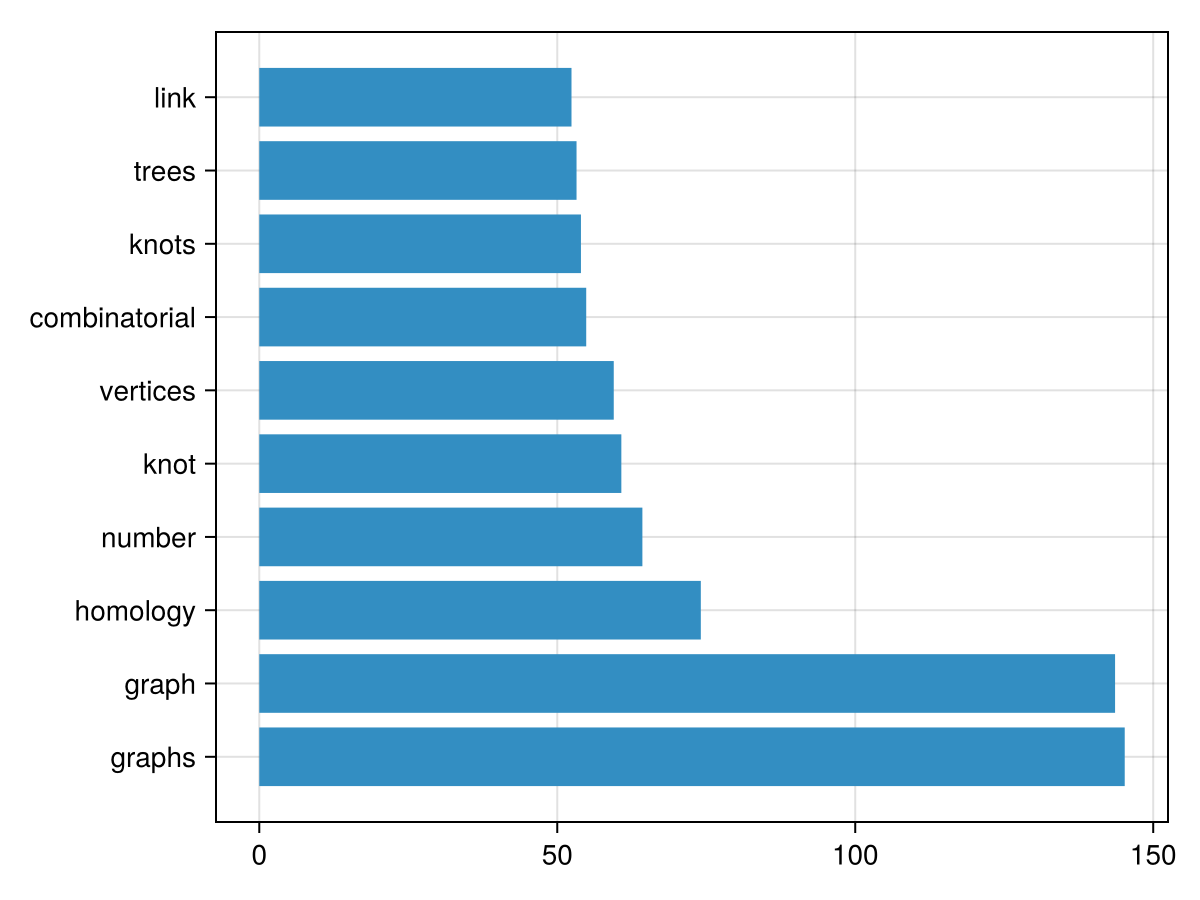

In [22]:
plot_topic_words(lda, vocab, 1)

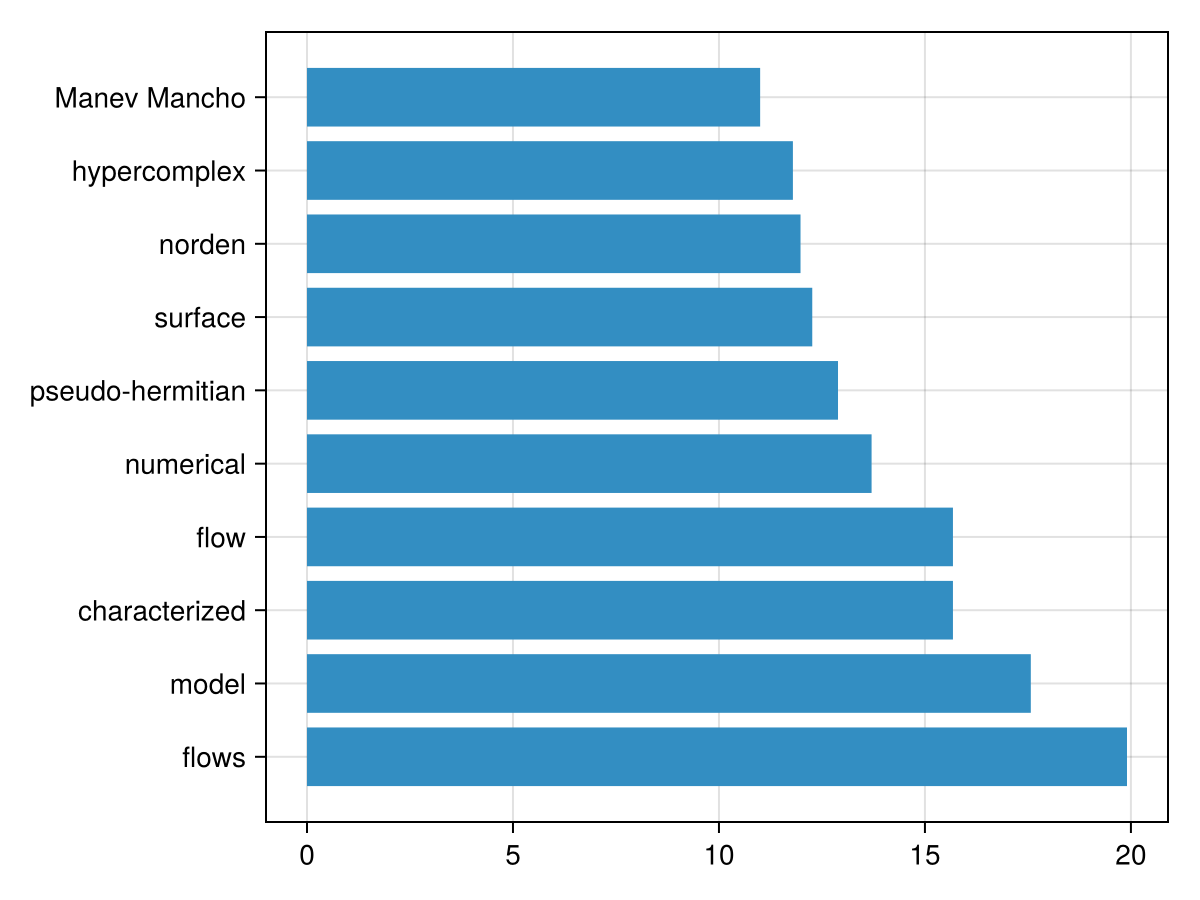

In [23]:
plot_topic_words(lda, vocab, 2)

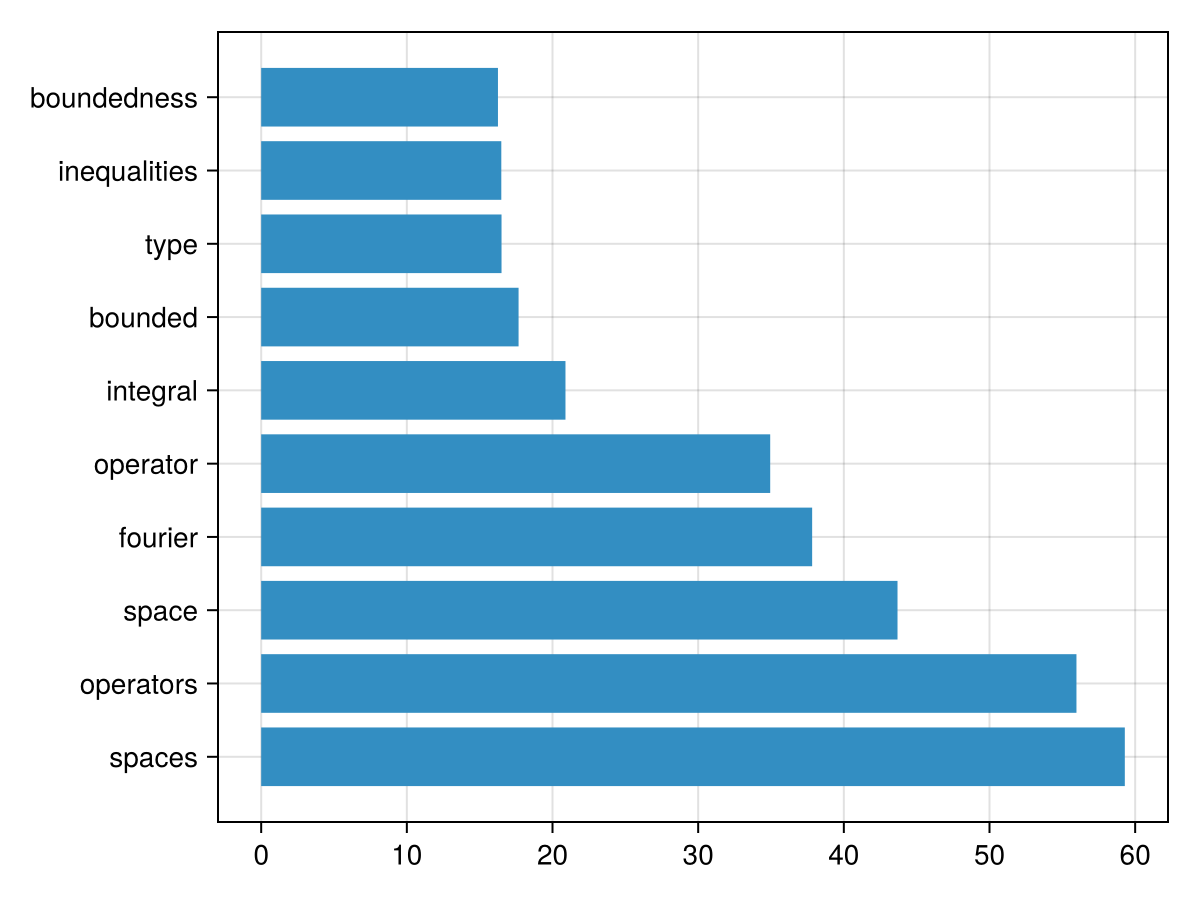

In [24]:
plot_topic_words(lda, vocab, 3)

In [25]:
word_weights = Dict{String, Float64}()
word_topic = Dict{String, Int}()
word_best_val = Dict{String, Float64}()

id2word = Dict(v => k for (k,v) in vocab)

Dict{Int64, String} with 25668 entries:
  19700 => "cb-multiplier"
  11950 => "finis"
  1703  => "represents"
  12427 => "Kubis Wieslaw"
  7685  => "dipole"
  18374 => "superstrictly"
  3406  => "subscheme"
  23970 => "doubts"
  2015  => "devices"
  1090  => "dependent"
  18139 => "superefficient"
  17088 => "ifn"
  11280 => "opulent"
  16805 => "Beck Matthias"
  3220  => "practical"
  11251 => "multimodal"
  422   => "because"
  15370 => "def"
  25327 => "professors"
  15859 => "pseudo-unitarizable"
  4030  => "paul"
  8060  => "multi-sample"
  14167 => "friction-induced"
  8660  => "replace"
  18475 => "castelnuovo--mumford"
  ⋮     => ⋮

In [26]:
top_n = 5

for i in 1:K
    word_counts = lda.Nkv_mean[i, :]

    top_ids = sortperm(word_counts, rev=true)[1:top_n]

    for j in top_ids
        word = id2word[j]
        val = word_counts[j]

        word_weights[word] = get(word_weights, word, 0.0) + val

        if !haskey(word_best_val, word) || val > word_best_val[word]
            word_best_val[word] = val
            word_topic[word] = i
        end
    end
end

In [27]:
colors = distinguishable_colors(K)

topic_color = Dict(i => colors[i] for i in 1:K)

Dict{Int64, RGB{FixedPointNumbers.N0f8}} with 30 entries:
  5  => RGB(0.886, 0.388, 0.051)
  16 => RGB(1.0, 0.361, 0.471)
  20 => RGB(1.0, 0.678, 0.027)
  12 => RGB(0.424, 0.322, 0.0)
  24 => RGB(0.369, 0.78, 0.0)
  28 => RGB(0.0, 0.561, 0.714)
  8  => RGB(0.675, 0.0, 0.278)
  17 => RGB(0.506, 0.592, 0.945)
  30 => RGB(0.769, 0.0, 0.0)
  1  => RGB(0.0, 0.0, 0.0)
  19 => RGB(0.78, 0.129, 0.867)
  22 => RGB(0.953, 1.0, 0.98)
  23 => RGB(0.0, 0.62, 0.533)
  6  => RGB(0.0, 0.494, 0.0)
  11 => RGB(1.0, 0.835, 0.769)
  9  => RGB(0.0, 1.0, 0.784)
  14 => RGB(0.267, 0.0, 0.361)
  3  => RGB(1.0, 0.608, 1.0)
  29 => RGB(0.812, 0.831, 0.992)
  7  => RGB(0.0, 0.314, 0.902)
  25 => RGB(0.0, 0.176, 0.329)
  4  => RGB(0.0, 0.827, 1.0)
  13 => RGB(0.478, 0.459, 0.506)
  15 => RGB(0.62, 0.62, 0.467)
  2  => RGB(1.0, 1.0, 0.455)
  ⋮  => ⋮

In [28]:
words = collect(keys(word_weights))

weights = [word_weights[w] for w in words]

colors_list = [
    haskey(word_topic, w) ? topic_color[word_topic[w]] : RGB(0.5,0.5,0.5)
    for w in words
]

angles = collect(0:5:180)
backgroundcolor = :maskcolor
shape(ellipse, 1000, 600, color="#8FB79C", padding=100, outline=4, linecolor="#ADEA821E")
▸1. Set spacing = 2; scale = 74.74149874931193
Completed after 65 epochs.


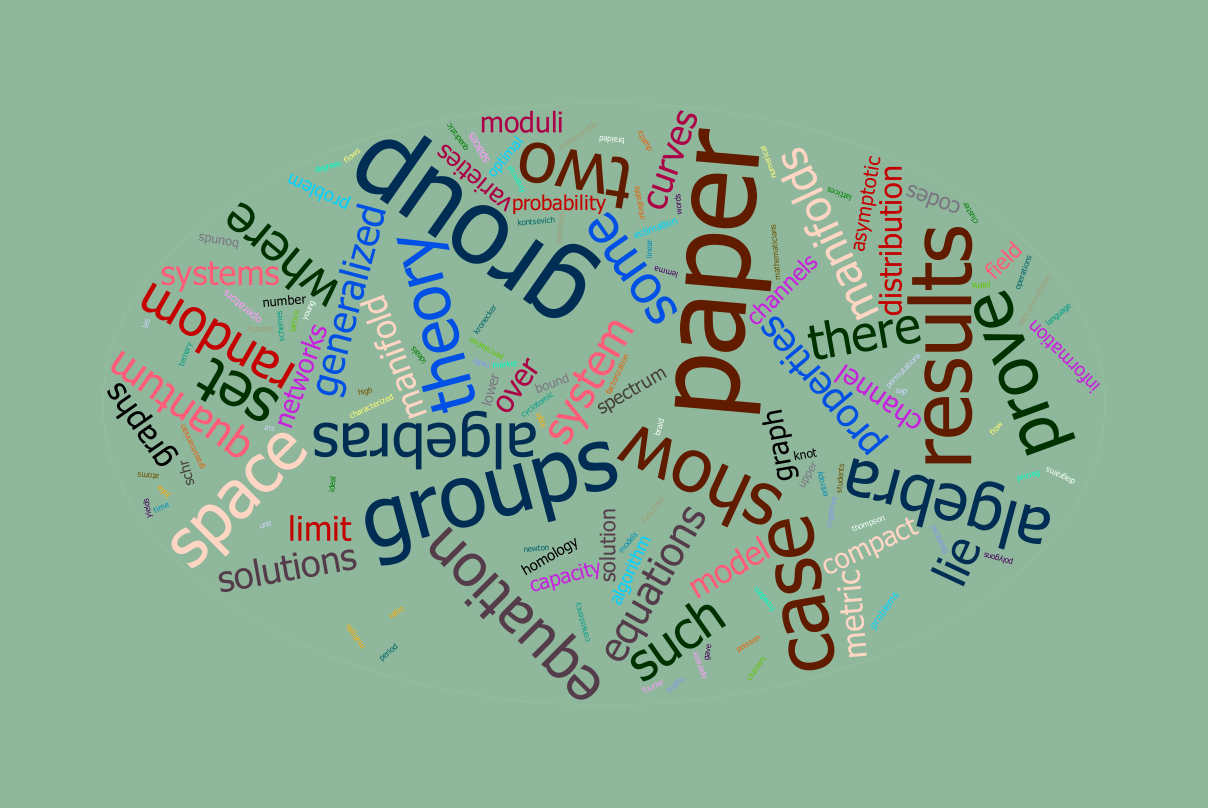

In [29]:
wc = wordcloud(
    words,
    weights;
    colors = colors_list,
    fonts = "Sans Not-Rotated",
    masksize = (1000, 600)
)

generate!(wc)

In [30]:
function eval_perplexity(x)
    return x.PPL
end


function build_topic_label_map(Ndk_mean, labels)

    K = size(Ndk_mean, 2)

    topic_to_labels = [Int[] for _ in 1:K]

    for d in 1:size(Ndk_mean, 1)

        topic = argmax(Ndk_mean[d, :])
        push!(topic_to_labels[topic], labels[d])
    end

    mapping = Dict{Int, Int}()

    for k in 1:K
        if isempty(topic_to_labels[k])
            continue
        end
        mapping[k] = mode(topic_to_labels[k])
    end

    return mapping
end

function majority_vote(v)

    counts = Dict{eltype(v), Int}()

    for x in v
        counts[x] = get(counts, x, 0) + 1
    end

    best_label = first(v)
    best_count = 0

    for (k, c) in counts
        if c > best_count
            best_label = k
            best_count = c
        end
    end

    return best_label
end

function lda_accuracy(Ndk_mean, labels)

    K = size(Ndk_mean, 2)

    topic_to_labels = [String[] for _ in 1:K]

    for d in 1:size(Ndk_mean, 1)

        topic = argmax(Ndk_mean[d, :])
        push!(topic_to_labels[topic], labels[d])
    end

    mapping = Dict{Int, String}()

    for k in 1:K

        if isempty(topic_to_labels[k])
            continue
        end

        mapping[k] = majority_vote(topic_to_labels[k])
    end

    correct = 0

    for d in 1:size(Ndk_mean, 1)

        topic = argmax(Ndk_mean[d, :])
        pred = get(mapping, topic, "")

        if pred == labels[d]
            correct += 1
        end
    end

    return correct / length(labels)
end

function lda_topic_purity(Ndk_mean, labels)

    K = size(Ndk_mean, 2)

    topic_labels = [String[] for _ in 1:K]

    for d in 1:size(Ndk_mean, 1)
        push!(topic_labels[argmax(Ndk_mean[d, :])], labels[d])
    end

    total = 0
    correct = 0

    for k in 1:K

        if isempty(topic_labels[k])
            continue
        end

        majority = majority_vote(topic_labels[k])

        correct += count(x -> x == majority, topic_labels[k])
        total += length(topic_labels[k])
    end

    return correct / total
end

function lda_topic_diversity(Nkv_mean; top_n=10)

    K = size(Nkv_mean, 1)

    top_words = Set{Int}()

    for k in 1:K

        scores = Nkv_mean[k, :]

        top_ids = partialsortperm(scores, 1:top_n, rev=true)

        for id in top_ids
            push!(top_words, id)
        end
    end

    return length(top_words) / (K * top_n)
end

function lda_coherence(Nkv_mean; top_n=10)

    K = size(Nkv_mean, 1)
    coherences = Float32[]

    for k in 1:K

        scores = Nkv_mean[k, :]
        top_ids = partialsortperm(scores, 1:top_n, rev=true)

        # proxy coherence: similarity in probability space
        sim = 0f0
        count = 0

        for i in 1:length(top_ids), j in i+1:length(top_ids)
            sim += min(scores[top_ids[i]], scores[top_ids[j]])
            count += 1
        end

        push!(coherences, sim / max(count, 1))
    end

    return mean(coherences)
end

function evaluate_lda(x, Ndk_mean, labels)

    println("=== LDA EVALUATION ===")

    ppl = x.PPL
    println("Perplexity: ", ppl)

    acc = lda_accuracy(Ndk_mean, labels)
    println("Accuracy (mapped topics): ", acc)

    purity = lda_topic_purity(Ndk_mean, labels)
    println("Topic purity: ", purity)

    div = lda_topic_diversity(x.Nkv_mean)
    println("Topic diversity: ", div)

    coh = lda_coherence(x.Nkv_mean)
    println("Topic coherence (proxy): ", coh)

    return (
        perplexity = ppl,
        accuracy = acc,
        purity = purity,
        diversity = div,
        coherence = coh
    )
end


evaluate_lda (generic function with 1 method)

In [31]:
evaluate_lda(lda, lda.Ndk_mean, df[train_idx, :].categories)

=== LDA EVALUATION ===
Perplexity: 9.154762961445211
Accuracy (mapped topics): 0.38059485994802195
Topic purity: 0.38059485994802195
Topic diversity: 0.8633333333333333
Topic coherence (proxy): 63.07748


(perplexity = 9.154762961445211, accuracy = 0.38059485994802195, purity = 0.38059485994802195, diversity = 0.8633333333333333, coherence = 63.07748f0)

In [50]:
include("BERTopicJL.jl")

run_pipeline (generic function with 1 method)

In [51]:
labels = df[!, :categories]

unique_labels = unique(labels)
label_to_idx = Dict(l => i for (i, l) in enumerate(unique_labels))

labels_encoded = [label_to_idx[l] for l in labels]

4329-element Vector{Int64}:
  1
  1
  1
  2
  3
  4
  3
  5
  6
  7
  8
  9
 10
  ⋮
  2
 24
  8
  9
  9
 23
 12
 22
  6
  6
 15
 10

In [52]:
function add_token!(vocab::Dict{String,Int}, token::AbstractString)
    if haskey(vocab, token)
        return vocab[token]
    else
        id = length(vocab) + 1
        vocab[token] = id
        return id
    end
end

add_token! (generic function with 1 method)

In [53]:
docs_encoded = [ [add_token!(vocab, w) for w in t] for t in docs]

4329-element Vector{Vector{Int64}}:
 [1, 2, 1, 3, 4, 5, 6, 7, 8, 2  …  10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
 [20, 21, 22, 23, 24, 25, 26, 27, 28, 29  …  47, 48, 49, 10, 50, 25, 51, 52, 53, 54]
 [55, 12, 11, 56, 57, 58, 7, 11, 59, 55  …  63, 64, 65, 66, 12, 67, 68, 69, 18, 19]
 [70, 71, 72, 73, 74, 75, 76, 77, 78, 79  …  104, 105, 106, 107, 108, 109, 73, 110, 111, 112]
 [113, 114, 75, 115, 116, 117, 118, 119, 120, 121  …  161, 65, 162, 116, 102, 163, 164, 165, 166, 167]
 [168, 169, 170, 171, 172, 173, 174, 175, 81, 176  …  213, 214, 161, 215, 216, 217, 16, 218, 219, 220]
 [221, 222, 114, 223, 224, 225, 226, 175, 227, 34  …  273, 274, 275, 72, 276, 277, 278, 279, 110, 280]
 [281, 282, 283, 284, 285, 249, 197, 44, 201, 286  …  281, 5, 282, 113, 283, 284, 288, 285, 289, 290]
 [291, 292, 293, 294, 295, 294, 78, 296, 297, 125  …  14, 46, 321, 295, 282, 322, 163, 323, 324, 325]
 [326, 84, 327, 11, 328, 329, 330, 331, 332, 333  …  356, 357, 358, 359, 360, 161, 361, 12, 362, 363]
 [364, 365,

In [54]:
dataset = DataSet(
    docs_encoded,
    labels_encoded
)

DataSet([[1, 2, 1, 3, 4, 5, 6, 7, 8, 2  …  10, 11, 12, 13, 14, 15, 16, 17, 18, 19], [20, 21, 22, 23, 24, 25, 26, 27, 28, 29  …  47, 48, 49, 10, 50, 25, 51, 52, 53, 54], [55, 12, 11, 56, 57, 58, 7, 11, 59, 55  …  63, 64, 65, 66, 12, 67, 68, 69, 18, 19], [70, 71, 72, 73, 74, 75, 76, 77, 78, 79  …  104, 105, 106, 107, 108, 109, 73, 110, 111, 112], [113, 114, 75, 115, 116, 117, 118, 119, 120, 121  …  161, 65, 162, 116, 102, 163, 164, 165, 166, 167], [168, 169, 170, 171, 172, 173, 174, 175, 81, 176  …  213, 214, 161, 215, 216, 217, 16, 218, 219, 220], [221, 222, 114, 223, 224, 225, 226, 175, 227, 34  …  273, 274, 275, 72, 276, 277, 278, 279, 110, 280], [281, 282, 283, 284, 285, 249, 197, 44, 201, 286  …  281, 5, 282, 113, 283, 284, 288, 285, 289, 290], [291, 292, 293, 294, 295, 294, 78, 296, 297, 125  …  14, 46, 321, 295, 282, 322, 163, 323, 324, 325], [326, 84, 327, 11, 328, 329, 330, 331, 332, 333  …  356, 357, 358, 359, 360, 161, 361, 12, 362, 363]  …  [4167, 25624, 249, 25625, 939, 331,

In [55]:
 model, test_docs, test_labels = run_pipeline(
        dataset;
        vocab_size=length(vocab)
    )

Preparing data...
Init embedder...
Building pairs...
Training embedder...
Epoch 1 loss = 0.1766707788814198
Epoch 2 loss = 0.035289815881035545
Epoch 3 loss = 0.0059514404697851705
Epoch 4 loss = 0.001983164386315779
Epoch 5 loss = 0.000901376066560095
Epoch 6 loss = 0.0005204610272564671
Epoch 7 loss = 0.0004934984343973073
Epoch 8 loss = 0.00039836865934458643
Epoch 9 loss = 0.00030485290864651853
Epoch 10 loss = 0.0003993503580039198
Building embeddings...
Discovering topics...
Building centroids...
Evaluating...
Accuracy = 0.0011547344110854503


(TopicModel(FluxEmbedder(Embedding(25668 => 256), Chain(Dense(256 => 256, relu), Dense(256 => 256))), Vector{Float32}[[-0.12037283, 0.01631222, -0.11013938, 0.003229531, -0.12297471, 0.016251672, 0.037249893, 0.033262197, 0.041144155, 0.058859475  …  -0.012834311, 0.008477515, -0.05518194, -0.06254376, -0.1399997, -0.008060382, -0.032657795, -0.056964602, 0.044221662, 0.115386434], [0.10508855, -0.03077775, -0.042790093, -0.038553413, -0.018604977, 0.057108406, -0.023111518, 0.028373538, 0.09472971, 0.036741298  …  -0.026578747, -0.08855871, -0.062275857, 0.00444486, -0.1179059, -0.015414775, 0.09840388, -0.04630049, -0.018390214, 0.04562204], [0.019881736, 0.045379844, 0.1020899, 0.044972755, -0.017899746, -0.1322633, 0.008932586, 0.001942372, 0.072932184, 0.076472886  …  -0.033966318, 0.0926482, -0.12303869, -0.09749911, -0.03720536, -0.04840266, -0.04938974, -0.022108631, -0.0018569051, 0.11048626], [-0.036744818, -0.037900522, -0.1115093, 0.023928078, -0.13733996, 0.070632346, -0.0

In [56]:
function doc_topic_matrix(model::TopicModel, docs)
    N = length(docs)
    K = length(model.topic_centroids)

    M = zeros(Float32, N, K)

    for i in 1:N
        d = embed(model.embedder, docs[i])

        for k in 1:K
            M[i, k] = cosine(d, model.topic_centroids[k])
        end
    end

    return M
end

function doc_topic_probs(model, docs)
    M = doc_topic_matrix(model, docs)
    for i in 1:size(M,1)
        v = M[i,:]
        v = exp.(v .- maximum(v))
        M[i,:] = v ./ sum(v)
    end
    return M
end

function topic_word_scores(model::TopicModel, vocab)
    id2word = Dict(v => k for (k, v) in vocab)

    V = maximum(values(vocab))
    K = length(model.topic_centroids)

    S = zeros(Float32, K, V)

    for (word, id) in vocab

        # embedding pojedynczego tokena
        wemb = embed(model.embedder, [id])

        for k in 1:K
            S[k, id] = cosine(model.topic_centroids[k], wemb)
        end
    end

    return S, id2word
end

function plot_topic_words(model::TopicModel, vocab, topic_id; top_n=10)

    S, id2word = topic_word_scores(model, vocab)

    word_scores = S[topic_id, :]

    top_ids = sortperm(word_scores, rev=true)[1:min(top_n, length(word_scores))]

    words = [id2word[i] for i in top_ids]
    values = word_scores[top_ids]

    fig = Figure()
    ax = Axis(fig[1, 1], yticks=(1:length(words), words))

    barplot!(ax, values; direction=:x)

    return fig
end

plot_topic_words (generic function with 2 methods)

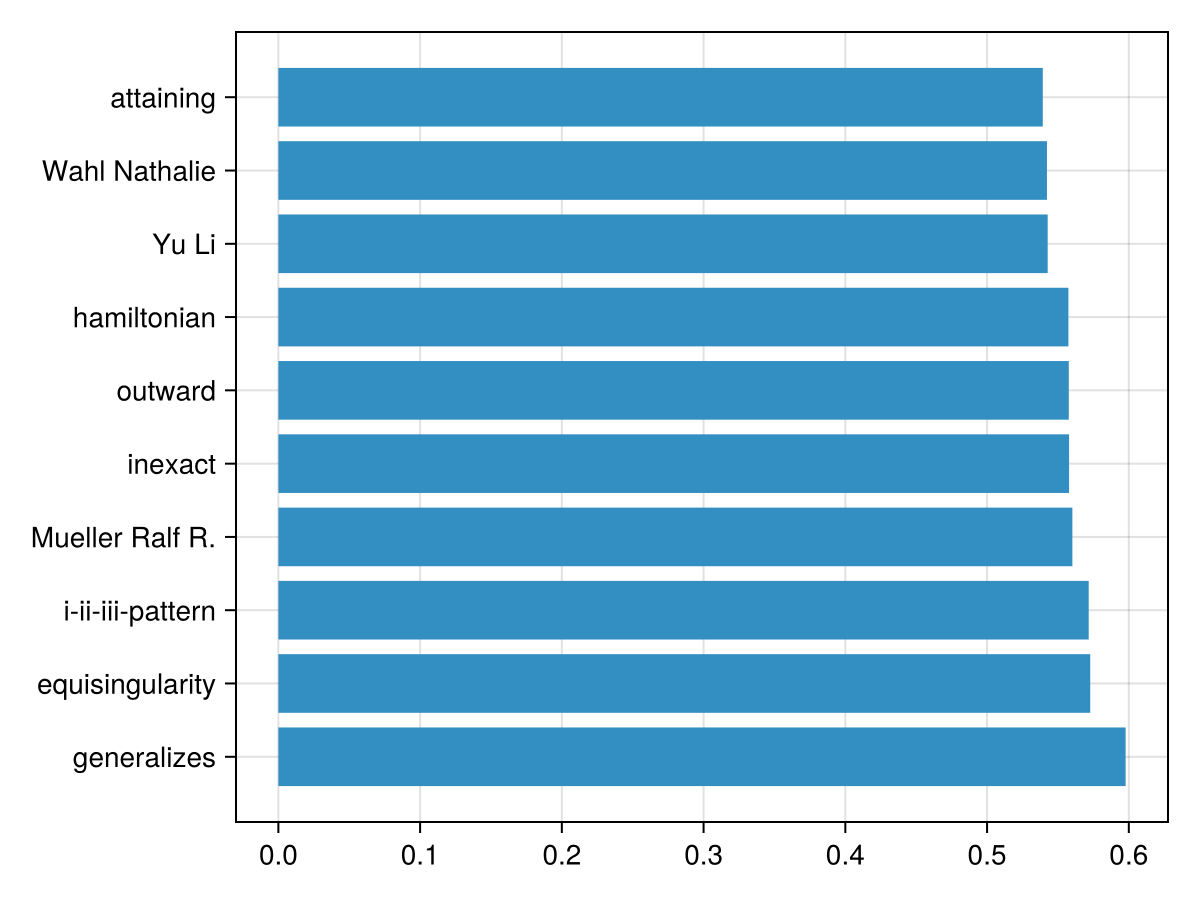

In [57]:
plot_topic_words(model, vocab, 1)

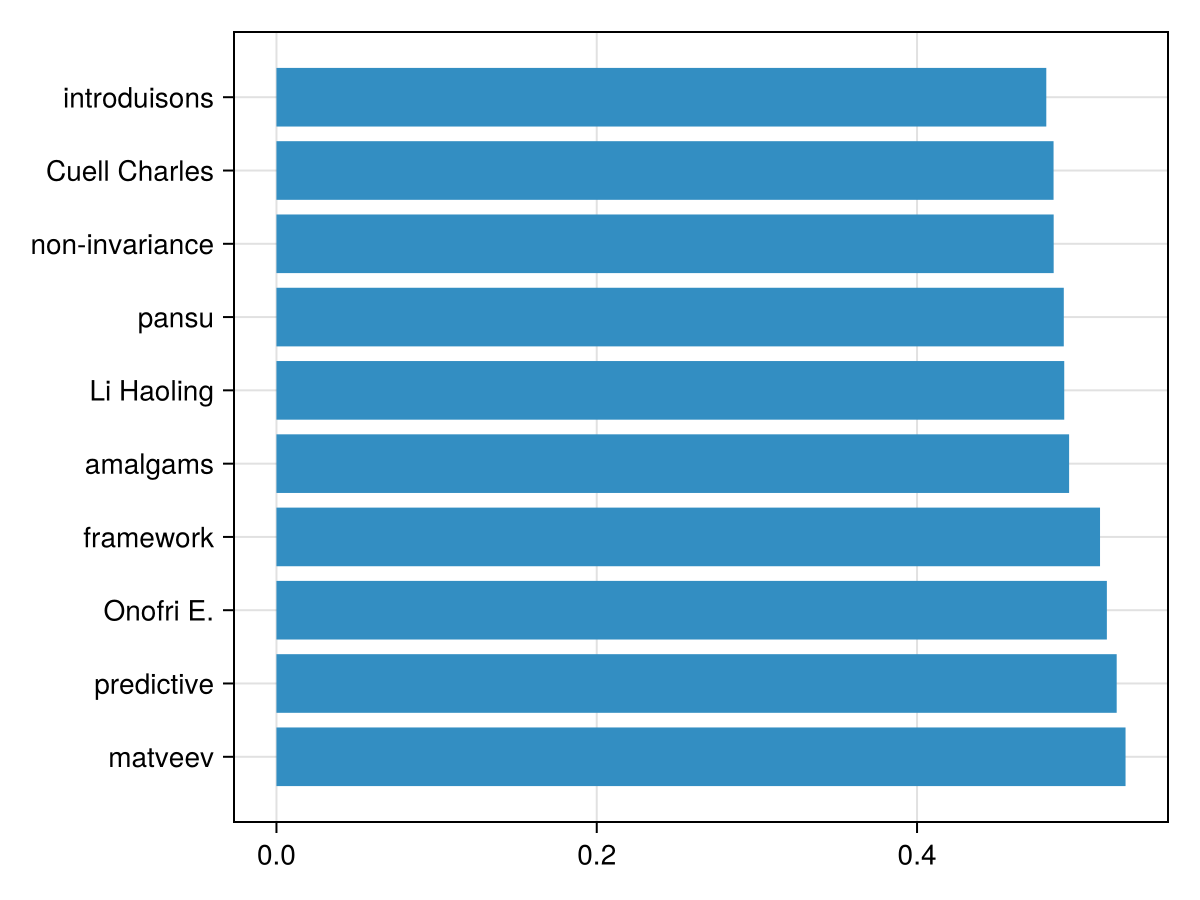

In [58]:
plot_topic_words(model, vocab, 2)

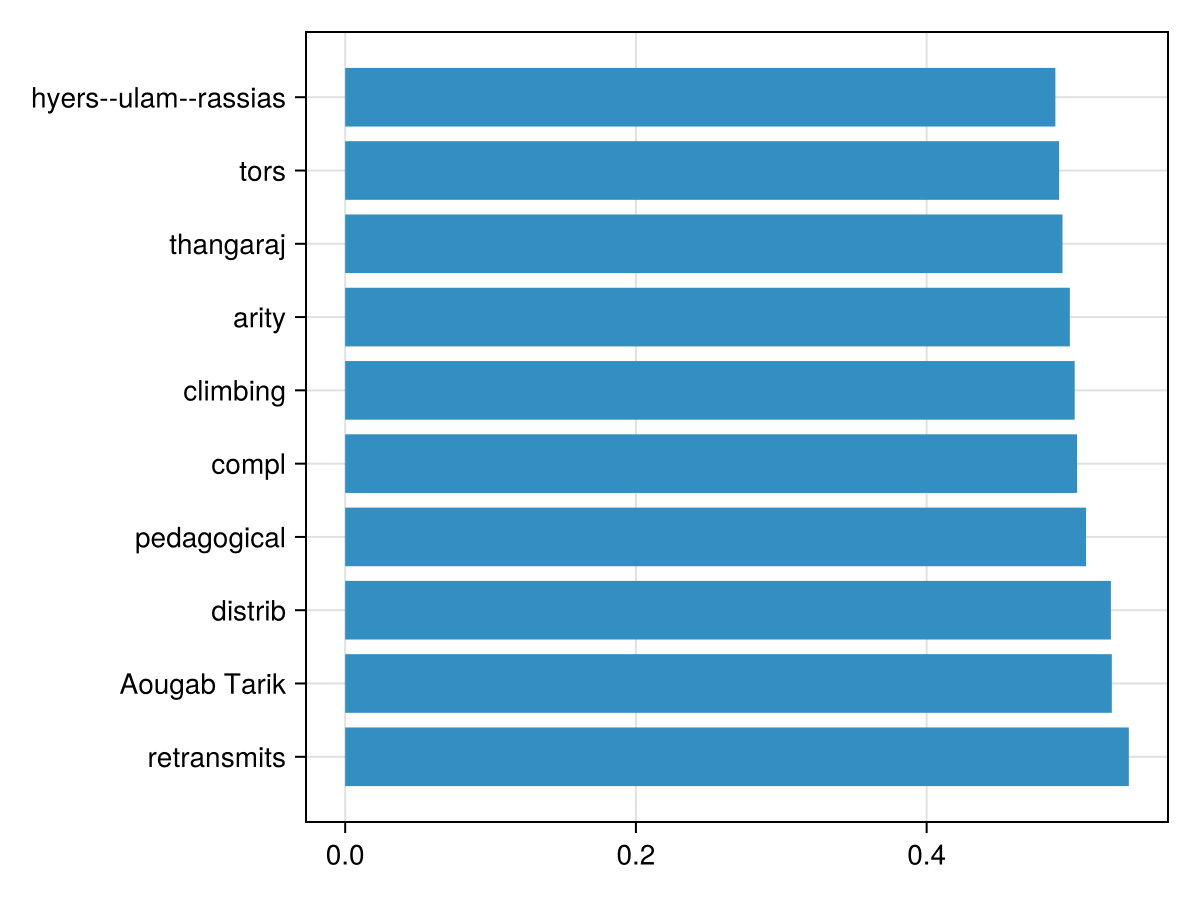

In [59]:
plot_topic_words(model, vocab, 3)

In [64]:
function evaluate_topics(preds, labels; centroids=nothing)

    K = maximum(preds)
    T = eltype(labels)

    topic_to_labels = [T[] for _ in 1:K]

    for i in eachindex(preds)
        push!(topic_to_labels[preds[i]], labels[i])
    end

    function majority_vote(v)

        counts = Dict{T,Int}()

        for x in v
            counts[x] = get(counts, x, 0) + 1
        end

        best_label = first(v)
        best_count = 0

        for (label, cnt) in counts
            if cnt > best_count
                best_label = label
                best_count = cnt
            end
        end

        return best_label
    end

    mapping = Dict{Int,T}()

    for k in 1:K
        if !isempty(topic_to_labels[k])
            mapping[k] = majority_vote(topic_to_labels[k])
        end
    end

    correct = 0

    for i in eachindex(preds)

        if haskey(mapping, preds[i]) &&
           mapping[preds[i]] == labels[i]
            correct += 1
        end
    end

    accuracy = correct / length(labels)

    total = 0
    correct_purity = 0

    for k in 1:K

        if isempty(topic_to_labels[k])
            continue
        end

        maj = majority_vote(topic_to_labels[k])

        correct_purity += count(x -> x == maj, topic_to_labels[k])
        total += length(topic_to_labels[k])
    end

    purity = correct_purity / max(total, 1)

    diversity = missing
    coherence = missing

    if centroids !== nothing

        all_features = Set{Int}()

        for c in centroids

            top = sortperm(c, rev=true)[1:min(10, length(c))]

            union!(all_features, top)
        end

        Kc = length(centroids)

        diversity = length(all_features) / (Kc * 10)

        coh = 0.0

        for i in 1:Kc
            for j in i+1:Kc
                coh += cosine(centroids[i], centroids[j])
            end
        end

        coherence = 1 - coh / max(Kc*(Kc-1)/2, 1)
    end

    return (
        accuracy = accuracy,
        purity = purity,
        diversity = diversity,
        coherence = coherence
    )
end

evaluate_topics (generic function with 1 method)

In [65]:
preds = [
    assign_topic(model, doc)[1]
    for doc in test_docs
]

results = evaluate_topics(
    preds,
    test_labels;
    centroids=model.topic_centroids
)

(accuracy = 0.8383371824480369, purity = 0.8383371824480369, diversity = 0.00743321718931475, coherence = 0.9431105781433983)